In [ ]:
#!jupyter nbconvert --to python GrabData.ipynb

[NbConvertApp] Converting notebook GrabData.ipynb to python
[NbConvertApp] Writing 10183 bytes to GrabData.py


In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
import json
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')  # Add parent directory to Python path
from PythonFiles.GrabData import getPlayerData, get_project_root, updateCsv
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path

In [21]:
# Data preprocessing
def prepare_data_for_ml(df, target_variable='win'):
    # Create copy of dataframe
    df_ml = df.copy()

    # Convert gameDuration from HH:MM:SS to total seconds
    df_ml['gameDuration'] = df_ml['gameDuration'].apply(lambda x: sum(int(i) * 60 ** idx for idx, i in enumerate(reversed(x.split(':')))))
    
    # Encode categorical variables
    categorical_columns = ['championName', 'role']
    le_dict = {}
    for col in categorical_columns:
        le = LabelEncoder()
        df_ml[col] = le.fit_transform(df_ml[col])
        le_dict[col] = le

    # Calculate derived features
    df_ml['kda'] = (df_ml['kills'] + df_ml['assists']) / (df_ml['deaths'] + 1)  # Add 1 to avoid division by zero
    df_ml['damage_per_min'] = df_ml['totalDamageDealtToChampions'] / (df_ml['gameDuration'] / 60)
    df_ml['vision_per_min'] = df_ml['visionScore'] / (df_ml['gameDuration'] / 60)
    
    # Select features for ML (removing redundant or irrelevant features)
    features = [
        'championName', 'role',
        'kda', 'damage_per_min', 'vision_per_min',
        'goldPerMinute', 'killParticipation',
        'maxCsAdvantageOnLaneOpponent', 'maxLevelLeadLaneOpponent',
        'visionScoreAdvantageLaneOpponent',
        'skillshotsHit', 'skillshotsDodged',
        'teamDamagePercentage', 'damageTakenOnTeamPercentage',
        'controlWardTimeCoverageInRiverOrEnemyHalf'
    ]
    
    # Separate features and target
    X = df_ml[features]
    y = df_ml[target_variable]
    
    # Scale the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Split the data with stratification
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    
    return X_scaled, X_train, X_test, y_train, y_test, scaler, le, features


In [7]:
def train_and_evaluate_model(X_train, X_test, y_train, y_test, features):
    # Initialize model
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        class_weight='balanced'  # Handle any class imbalance
    )
    
    # Train model
    model.fit(X_train, y_train)
    
    # Evaluate model
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    
    print(f"Train accuracy: {train_score:.3f}")
    print(f"Test accuracy: {test_score:.3f}")
    
    # Detailed classification report
    y_pred = model.predict(X_test)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Feature importance analysis
    feature_importance = pd.DataFrame({
        'feature': features,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
    plt.title('Top 10 Most Important Features')
    plt.show()
    
    return model

In [19]:
# Usage
def main():
    # Load your data
    updateCsv()
    project_root = get_project_root()
    csv_path = project_root / 'Data/league_matches.csv'
    df = pd.read_csv(csv_path)
    
    # Prepare data
    scaledDataFrame, X_train, X_test, y_train, y_test, scaler, le_dict, features = prepare_data_for_ml(df)
    
    # Train and evaluate model
    model = train_and_evaluate_model(X_train, X_test, y_train, y_test, features)
    
    return scaledDataFrame, model, scaler, le_dict

In [23]:
def displayPredictionHistogram(predictedProbability):

    plt.figure(figsize=(10, 6))
    plt.hist(predictedProbability, bins=10, edgecolor='black', color='skyblue')
    plt.title('Distribution of Predicted Win Probabilities')
    plt.xlabel('Win Probability')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Successfully saved data to d:\Projects\RiotProject\LeagueDataFarm\Data\league_matches.csv
Train accuracy: 1.000
Test accuracy: 0.667

Classification Report:
              precision    recall  f1-score   support

       False       0.67      0.67      0.67         3
        True       0.67      0.67      0.67         3

    accuracy                           0.67         6
   macro avg       0.67      0.67      0.67         6
weighted avg       0.67      0.67      0.67         6



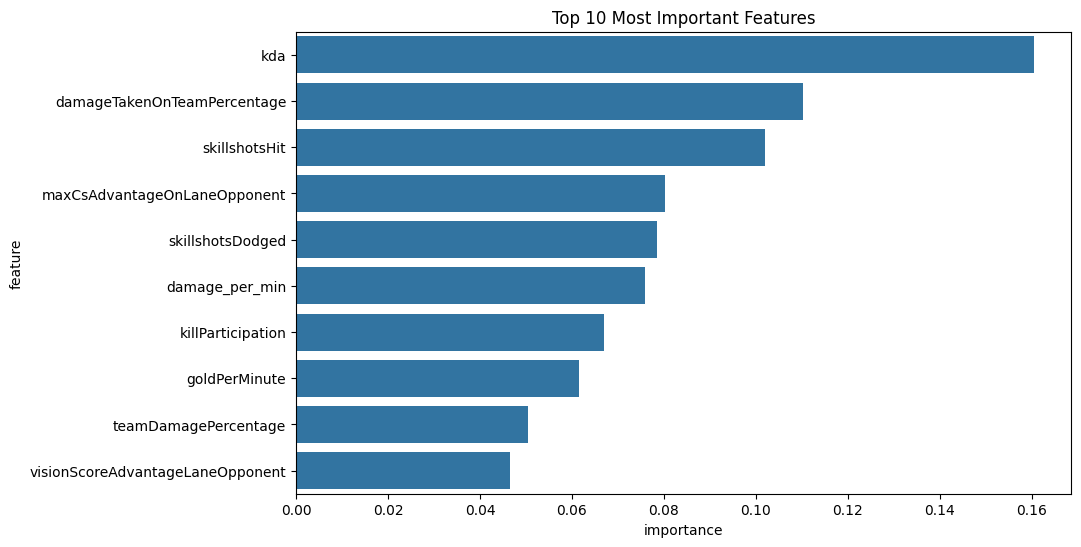

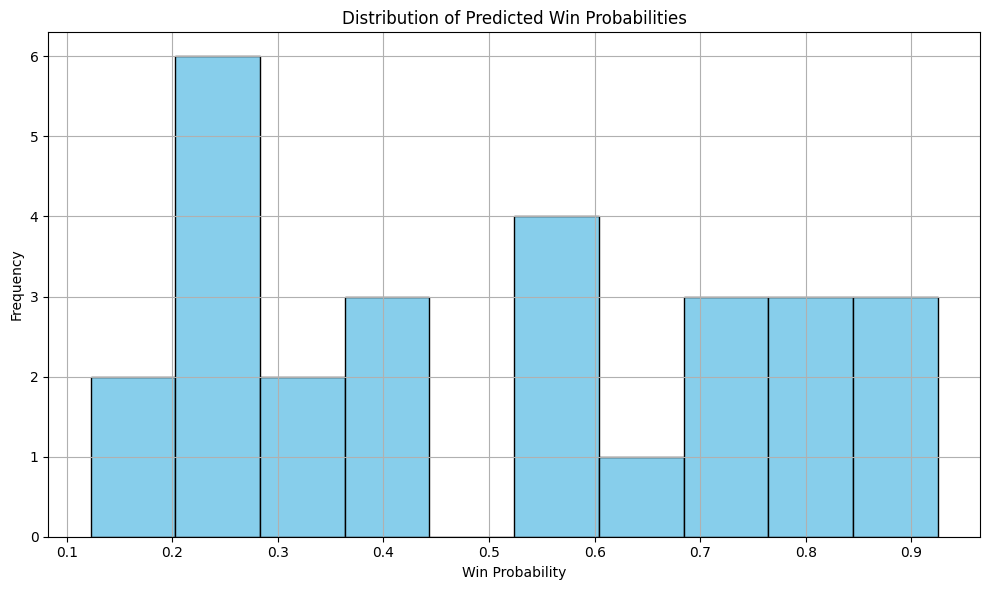

In [24]:
# Run the main function
scaledDataFrame, model, scaler, le_dict = main()

# Make predictions on new data
def predict_win_probability(new_data, model):
    # Preprocess new data using the same scalers and encoders
    # Return win probability
    return model.predict_proba(new_data)[:, 1]

probabilities = predict_win_probability(scaledDataFrame, model)
displayPredictionHistogram(probabilities)
